# OFDM-based Communications with Superimposed Pilots

This notebook provides an implementation of superimposed pilots for OFDM communication systems, based on the approach presented in "[End-to-End Learning for OFDM: From Neural Receivers to Pilotless Communication](https://ieeexplore.ieee.org/abstract/document/9508784)" [1].

We focus specifically on neural network-based receivers that leverage superimposed pilot signals.

## Configuration and Imports

In [1]:
# Import Sionna
try:
    import sionna.phy
except ImportError as e:
    import os
    import sys
    if 'google.colab' in sys.modules:
       # Install Sionna in Google Colab
       print("Installing Sionna and restarting the runtime. Please run the cell again.")
       os.system("pip install sionna")
       os.kill(os.getpid(), 5)
    else:
       raise e

import math
import numpy as np

# For plotting
%matplotlib inline
import matplotlib.pyplot as plt

# For the implementation of the neural receiver
import torch
import torch.nn as nn
import torch.nn.functional as F

from sionna.phy import Block
from sionna.phy.channel.tr38901 import Antenna, AntennaArray, CDL
from sionna.phy.channel import OFDMChannel
from sionna.phy.mimo import StreamManagement
from sionna.phy.ofdm import (
    ResourceGrid,
    ResourceGridMapper,
    ResourceGridDemapper,
    LSChannelEstimator,
    LMMSEEqualizer,
    RemoveNulledSubcarriers,
)
from sionna.phy.utils import ebnodb2no, insert_dims, expand_to_rank, sim_ber, PlotBER
from sionna.phy.fec.ldpc import LDPC5GEncoder, LDPC5GDecoder
from sionna.phy.mapping import Mapper, Demapper, BinarySource, QAMSource

# Set seed for reproducible results
sionna.phy.config.seed = 42
device = sionna.phy.config.device

## Simulation Parameters

In [2]:
# Bit per channel use
NUM_BITS_PER_SYMBOL = 2 # QPSK

# Minimum value of Eb/N0 [dB] for simulations
EBN0_DB_MIN = 0.0

# Maximum value of Eb/N0 [dB] for simulations
EBN0_DB_MAX = 10.0

# How many examples are processed by Sionna in parallel
BATCH_SIZE = 128

# Coding rate
CODERATE = 0.5

# Number of convolutional channels
NUM_CONV_CHANNELS = 128

# Create an RX-TX association matrix.
# RX_TX_ASSOCIATION[i,j]=1 means that receiver i gets at least one stream
# from transmitter j. Depending on the transmission direction (uplink or downlink),
# the role of UT and BS can change.
# For example, considering a system with 2 RX and 4 TX, the RX-TX
# association matrix could be
# [ [1 , 1, 0, 0],
#   [0 , 0, 1, 1] ]
# which indicates that the RX 0 receives from TX 0 and 1, and RX 1 receives from
# TX 2 and 3.
#
# In this notebook, as we have only a single transmitter and receiver,
# the RX-TX association matrix is simply:
RX_TX_ASSOCIATION = np.array([[1]])

# Instantiate a StreamManagement object
# This determines which data streams are determined for which receiver.
# In this simple setup, this is fairly easy. However, it can get more involved
# for simulations with many transmitters and receivers.
STREAM_MANAGEMENT = StreamManagement(RX_TX_ASSOCIATION, 1)

# Resource grid configuration without DMRS pilots for superimposed pilot transmission
RESOURCE_GRID_0P = ResourceGrid(num_ofdm_symbols=14,
                                fft_size=76,
                                subcarrier_spacing=30e3,
                                num_tx=1,
                                num_streams_per_tx=1,
                                cyclic_prefix_length=6)

# Resource grid configuration with two DMRS pilots for baseline comparison
RESOURCE_GRID_2P = ResourceGrid(num_ofdm_symbols=14,
                                fft_size=76,
                                subcarrier_spacing=30e3,
                                num_tx=1,
                                num_streams_per_tx=1,
                                pilot_pattern="kronecker",
                                pilot_ofdm_symbol_indices=[2,11],
                                cyclic_prefix_length=6)

# Grid dimensions for neural network
NUM_OFDM_SYMBOLS = RESOURCE_GRID_0P.num_ofdm_symbols
FFT_SIZE = RESOURCE_GRID_0P.fft_size

# Carrier frequency in Hz.
CARRIER_FREQUENCY = 2.6e9

# Antenna setting
UT_ARRAY = Antenna(polarization="single",
                   polarization_type="V",
                   antenna_pattern="omni",
                   carrier_frequency=CARRIER_FREQUENCY)
BS_ARRAY = AntennaArray(num_rows=1,
                        num_cols=1,
                        polarization="single",
                        polarization_type="V",
                        antenna_pattern="omni",
                        carrier_frequency=CARRIER_FREQUENCY)

# Nominal delay spread in [s]. Please see the CDL documentation
# about how to choose this value.
DELAY_SPREAD = 100e-9

# The `direction` determines if the UT or BS is transmitting.
# In the `uplink`, the UT is transmitting.
DIRECTION = "uplink"

# Suitable values are ["A", "B", "C", "D", "E"]
CDL_MODEL = "C"

# UT speed [m/s]. BSs are always assumed to be fixed.
# The direction of travel will chosen randomly within the x-y plane.
SPEED = 3.0

# Configure a channel impulse response (CIR) generator for the CDL model.
CDL_CHANNEL = CDL(CDL_MODEL,
                  DELAY_SPREAD,
                  CARRIER_FREQUENCY,
                  UT_ARRAY,
                  BS_ARRAY,
                  DIRECTION,
                  min_speed=SPEED)

Let's inspect the two OFDM resource grids.

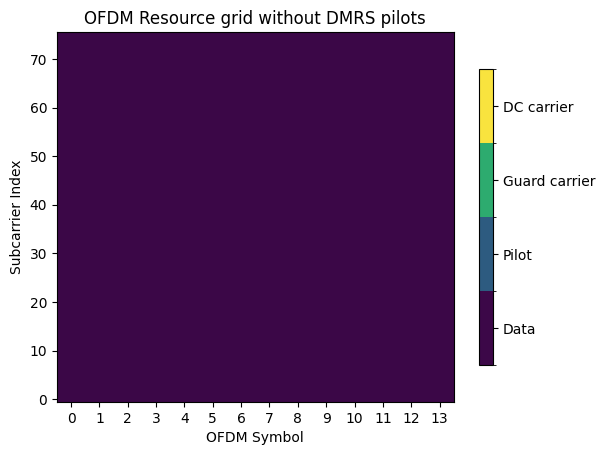

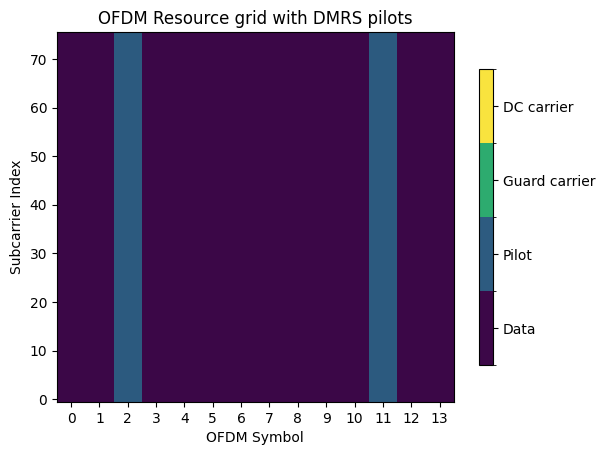

In [3]:
# Resource grid without DMRS pilots
plot = RESOURCE_GRID_0P.show();
plt.title("OFDM Resource grid without DMRS pilots");

# Resource grid with DMRS pilots
plot = RESOURCE_GRID_2P.show();
plt.title("OFDM Resource grid with DMRS pilots");

## Neural Receiver

The next cell defines the PyTorch modules that implement the neural receiver.
Convolutional layers are leveraged to efficiently process the 2D resource grid that is fed as input to the neural receiver and residual (skip) connections are used to prevent gradient vanishing during training [2].

For convenience, a PyTorch module that implements a *residual block* is first defined. The neural receiver is then built by stacking multiple such blocks. The following figure shows the architecture of the neural receiver.

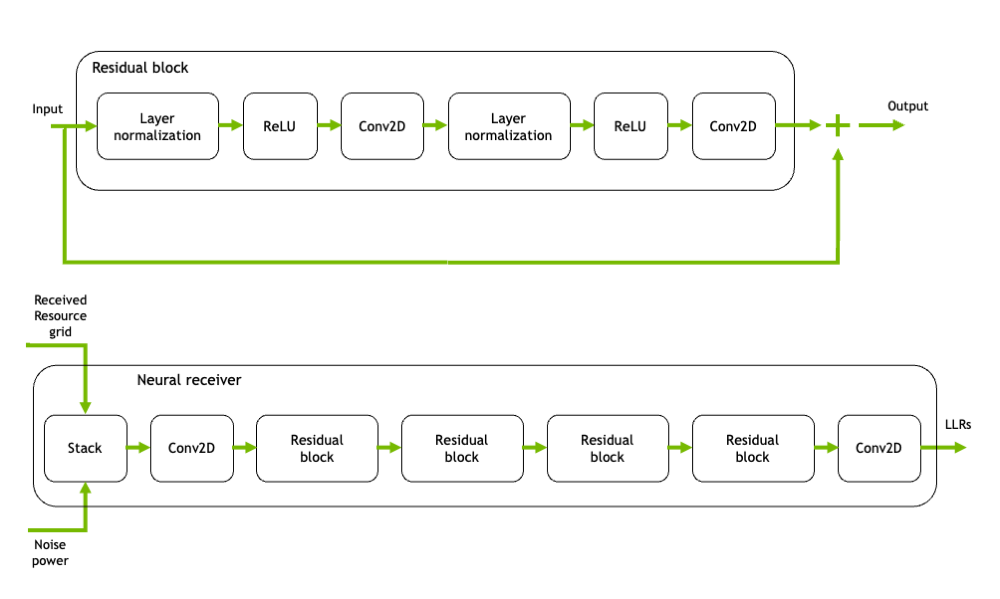

In [4]:
class ResidualBlock(nn.Module):
    """
    Convolutional residual block with two convolutional layers, ReLU activation,
    layer normalization, and a skip connection.

    The number of convolutional channels of the input must match num_conv_channels
    for the skip connection to work.

    Input shape: [batch_size, num_conv_channels, num_ofdm_symbols, num_subcarriers]
    Output shape: [batch_size, num_conv_channels, num_ofdm_symbols, num_subcarriers]
    """

    def __init__(self, num_conv_channels: int, num_ofdm_symbols: int, fft_size: int):
        super().__init__()
        # Layer normalization over the last three dimensions (C, H, W)
        self._layer_norm_1 = nn.LayerNorm([num_conv_channels, num_ofdm_symbols, fft_size])
        self._conv_1 = nn.Conv2d(
            in_channels=num_conv_channels,
            out_channels=num_conv_channels,
            kernel_size=3,
            padding=1,  # 'same' padding
        )
        self._layer_norm_2 = nn.LayerNorm([num_conv_channels, num_ofdm_symbols, fft_size])
        self._conv_2 = nn.Conv2d(
            in_channels=num_conv_channels,
            out_channels=num_conv_channels,
            kernel_size=3,
            padding=1,
        )

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        z = self._layer_norm_1(inputs)
        z = F.relu(z)
        z = self._conv_1(z)
        z = self._layer_norm_2(z)
        z = F.relu(z)
        z = self._conv_2(z)
        # Skip connection
        z = z + inputs
        return z


class NeuralReceiver(nn.Module):
    """
    Residual convolutional neural receiver for superimposed pilots.

    This neural receiver is fed with the post-DFT received samples, forming a
    resource grid of size num_ofdm_symbols x fft_size, and computes LLRs on
    the transmitted coded bits.

    Input
    -----
    y : [batch_size, num_rx, num_rx_antenna, num_ofdm_symbols, num_subcarriers], complex
        Received post-DFT samples.
    no : [batch_size], float
        Noise variance.

    Output
    ------
    llr : [batch_size, 1, 1, num_ofdm_symbols, num_subcarriers, num_bits_per_symbol], float
        LLRs on the transmitted bits.
    """

    def __init__(
        self,
        num_conv_channels: int,
        num_bits_per_symbol: int,
        num_ofdm_symbols: int,
        fft_size: int,
    ):
        super().__init__()
        self._num_bits_per_symbol = num_bits_per_symbol
        self._num_ofdm_symbols = num_ofdm_symbols
        self._fft_size = fft_size

        # Input convolution: 2*num_rx_antenna + 1 input channels (real, imag, noise)
        # For single antenna: 2*1 + 1 = 3 input channels
        num_input_channels = 2 * 1 + 1
        self._input_conv = nn.Conv2d(
            in_channels=num_input_channels,
            out_channels=num_conv_channels,
            kernel_size=3,
            padding=1,
        )
        # Residual blocks
        self._res_block_1 = ResidualBlock(num_conv_channels, num_ofdm_symbols, fft_size)
        self._res_block_2 = ResidualBlock(num_conv_channels, num_ofdm_symbols, fft_size)
        self._res_block_3 = ResidualBlock(num_conv_channels, num_ofdm_symbols, fft_size)
        self._res_block_4 = ResidualBlock(num_conv_channels, num_ofdm_symbols, fft_size)
        # Output convolution
        self._output_conv = nn.Conv2d(
            in_channels=num_conv_channels,
            out_channels=num_bits_per_symbol,
            kernel_size=3,
            padding=1,
        )

    def forward(self, y: torch.Tensor, no: torch.Tensor) -> torch.Tensor:
        # y: [batch, num_rx, num_rx_ant, num_ofdm_symbols, num_subcarriers]
        # no: [batch]

        # Assuming a single receiver, remove the num_rx dimension
        y = y.squeeze(1)  # [batch, num_rx_ant, num_ofdm_symbols, num_subcarriers]

        # Feeding the noise power in log10 scale helps with the performance
        no_log = torch.log10(no)

        # Stack real and imaginary components
        y_real = y.real  # [batch, num_rx_ant, time, freq]
        y_imag = y.imag  # [batch, num_rx_ant, time, freq]

        # Reshape noise to [batch, 1, 1, 1] and broadcast
        batch_size = y.shape[0]
        no_expanded = no_log.view(-1, 1, 1, 1)
        no_expanded = no_expanded.expand(batch_size, 1, y.shape[2], y.shape[3])

        # Concatenate: [batch, 2*num_rx_ant + 1, time, freq]
        z = torch.cat([y_real, y_imag, no_expanded], dim=1)

        # Input conv
        z = self._input_conv(z)
        # Residual blocks
        z = self._res_block_1(z)
        z = self._res_block_2(z)
        z = self._res_block_3(z)
        z = self._res_block_4(z)
        # Output conv: [batch, num_bits_per_symbol, time, freq]
        z = self._output_conv(z)

        # Transpose to [batch, time, freq, num_bits_per_symbol]
        z = z.permute(0, 2, 3, 1)

        # Reshape the input to fit what the resource grid demapper expects
        # Add dimensions for num_rx and num_rx_ant: [batch, 1, 1, time, freq, num_bits_per_symbol]
        z = insert_dims(z, 2, 1)

        return z

The following cell defines the end-to-end OFDM system with superimposed pilots.
 
Let $N$ denote the number of subcarriers and $M$ the number of OFDM symbols.
The transmitter implementation follows the architecture shown in the figure below. Coded bits are first mapped to a QAM constellation and then arranged into a resource grid $\mathbf{X}_{\text{d}}$ that *contains only data symbols (no pilots)*.
A separate resource grid that contains fixed QPSK pilot symbols is then *superimposed* onto the data resource grid $\mathbf{X}_{\text{d}}$ according to:

\begin{equation}
\mathbf{X} = \sqrt{1-\alpha} \mathbf{X}_{\text{d}} + \sqrt{\alpha}\mathbf{X}_{\text{p}}
\end{equation}

where $\boldsymbol{\alpha} \in \mathbb{R}^{N \times M}$ is a *trainable* power allocation matrix such that $0 \leq \alpha_{n,m} \leq 1$ for all $n = 1,\ldots,N$ and $m = 1,\ldots,M$. Each element $\alpha_{n,m}$ represents the fraction of energy allocated to pilots at resource element $(n,m)$. The square roots and products in the equation are applied element-wise.

![sip notebook.png](attachment:08818eeb-b1c9-4d7c-a82a-0576fcefcbcd.png)

Training of the end-to-end system is done on the bit-metric decoding (BMD) rate [3] which is computed from the transmitted bits and LLRs:

\begin{equation}
R = 1 - \frac{1}{SNMK} \sum_{s = 0}^{S-1} \sum_{n = 0}^{N-1} \sum_{m = 0}^{M-1} \sum_{k = 0}^{K-1} \texttt{BCE} \left( B_{s,n,m,k}, \texttt{LLR}_{s,n,m,k} \right)
\end{equation}

where

* $S$ is the batch size
* $K$ the number of bits per symbol
* $B_{s,n,m,k}$ the $k^{th}$ coded bit transmitted on the resource element $(n,m)$ and for the $s^{th}$ batch example
* $\texttt{LLR}_{s,n,m,k}$ the LLR (logit) computed by the neural receiver corresponding to the $k^{th}$ coded bit transmitted on the resource element $(n,m)$ and for the $s^{th}$ batch example
* $\texttt{BCE} \left( \cdot, \cdot \right)$ the binary cross-entropy in log base 2

Because no outer code is required at training, the outer encoder and decoder are not used at training to reduce computational complexity.

In [5]:
class OFDMSystemNeuralReceiver(Block):
    """
    End-to-end OFDM system with neural receiver and superimposed pilots.

    When training=True, returns the BMD rate loss for training.
    When training=False, returns (bits, bits_hat) for BER evaluation.
    """

    def __init__(self, training: bool = False):
        super().__init__()
        self._training = training

        n = int(RESOURCE_GRID_0P.num_data_symbols * NUM_BITS_PER_SYMBOL)
        k = int(n * CODERATE)
        self._k = k
        self._n = n

        # Transmitter components
        self._binary_source = BinarySource()
        if not training:
            self._encoder = LDPC5GEncoder(k, n)
        self._mapper = Mapper("qam", NUM_BITS_PER_SYMBOL)
        self._rg_mapper = ResourceGridMapper(RESOURCE_GRID_0P)

        # Channel
        self._channel = OFDMChannel(
            CDL_CHANNEL,
            RESOURCE_GRID_0P,
            add_awgn=True,
            normalize_channel=True,
            return_channel=False,
        )

        # Neural receiver
        self._neural_receiver = NeuralReceiver(
            NUM_CONV_CHANNELS,
            NUM_BITS_PER_SYMBOL,
            NUM_OFDM_SYMBOLS,
            FFT_SIZE,
        ).to(device)

        # Resource grid demapper
        self._rg_demapper = ResourceGridDemapper(RESOURCE_GRID_0P, STREAM_MANAGEMENT)

        # Decoder (only for evaluation)
        if not training:
            self._decoder = LDPC5GDecoder(self._encoder, hard_out=True)

        # Generate superimposed pilots
        # A fixed resource grid of superimposed pilots is randomly generated
        # by sampling a QPSK constellation
        pilot_source = QAMSource(num_bits_per_symbol=2, seed=1)
        pilots = pilot_source([1, 1, 1, RESOURCE_GRID_0P.num_ofdm_symbols, RESOURCE_GRID_0P.fft_size])
        # Center the pilots (remove DC component)
        mean = torch.mean(pilots)
        pilots = pilots - mean
        # Normalize the pilots
        norm_factor = torch.sqrt(torch.mean(torch.abs(pilots) ** 2))
        pilots = pilots / norm_factor
        # Move to device and register as buffer (not trainable, but saved with state_dict)
        self.register_buffer("_pilots", pilots.to(device))

        # Trainable variable that controls the amount of energy allocated to the pilots
        # We train its logits, i.e., the actual scaling is obtained by applying a sigmoid
        self._scaling_logit = nn.Parameter(torch.randn(pilots.shape, device=device))

    def forward(self, batch_size: int, ebno_db: torch.Tensor):
        # Compute noise power
        no = ebnodb2no(
            ebno_db,
            num_bits_per_symbol=NUM_BITS_PER_SYMBOL,
            coderate=CODERATE,
            resource_grid=RESOURCE_GRID_0P,
        )

        # Ensure no has shape [batch_size]
        if no.dim() == 0:
            no = no.expand(batch_size)

        # Transmitter
        if self._training:
            # Skip outer coding during training
            codewords = self._binary_source([batch_size, 1, 1, self._n])
        else:
            bits = self._binary_source([batch_size, 1, 1, self._k])
            codewords = self._encoder(bits)

        # Map data to constellation symbols
        x = self._mapper(codewords)
        # Map symbols to resource grid
        x_data = self._rg_mapper(x)

        # Add superimposed pilots
        scaling = torch.sigmoid(self._scaling_logit)
        scaling = torch.complex(scaling, torch.zeros_like(scaling))
        x_rg = torch.sqrt(1.0 - scaling) * x_data + torch.sqrt(scaling) * self._pilots

        # Channel
        no_expanded = expand_to_rank(no, x_rg.ndim)
        y = self._channel(x_rg, no_expanded)

        # Receiver
        llr = self._neural_receiver(y, no)
        llr = self._rg_demapper(llr)  # Extract data-carrying resource elements
        llr = llr.reshape(batch_size, 1, 1, self._n)

        if self._training:
            # Compute BCE loss for BMD rate
            bce = F.binary_cross_entropy_with_logits(
                llr, codewords.float(), reduction="none"
            )
            bce = bce.mean()
            # BMD rate
            rate = 1.0 - bce / math.log(2.0)
            return rate
        else:
            # Decode
            bits_hat = self._decoder(llr)
            return bits, bits_hat

## Training

The following cell implements a training loop that performs stochastic gradient descent (SGD) optimization using PyTorch.

Each training iteration consists of:
- Sampling a batch of signal-to-noise ratios $E_b/N_0$, where $E_b$ is the energy per bit and $N_0$ is the noise variance
- Executing a forward pass through the end-to-end system
- Computing gradients using PyTorch's autograd and applying them via the Adam optimizer
- Periodically displaying the current BMD rate to monitor training progress
 
Upon completion, the trained model weights are saved to a file for later use.
 
**Note:** Training may require significant computational time. For convenience, [pre-trained weights are available for download](https://drive.google.com/file/d/1GAgLXQxpqcVb1skHKLYPsWM4P-N3XqEV/view?usp=sharing). Skip executing the next cell if you prefer to use the pre-trained model instead of training from scratch.

In [ ]:
# Instantiating the end-to-end model for training
model = torch.compile(OFDMSystemNeuralReceiver(training=True), mode="reduce-overhead")

# Number of iterations used for training
NUM_TRAINING_ITERATIONS = 5000

# Adam optimizer (SGD variant)
optimizer = torch.optim.Adam(model.parameters())

# Training loop
for i in range(NUM_TRAINING_ITERATIONS):
    # Sample a batch of SNRs
    ebno_db = torch.empty(BATCH_SIZE, device=device).uniform_(EBN0_DB_MIN, EBN0_DB_MAX)
    
    # Forward pass
    optimizer.zero_grad()
    rate = model(BATCH_SIZE, ebno_db)
    
    # Loss is negative rate (we maximize rate by minimizing negative rate)
    loss = -rate
    
    # Backward pass
    loss.backward()
    optimizer.step()
    
    # Print progress
    if i % 100 == 0:
        print(f"{i}/{NUM_TRAINING_ITERATIONS}  Rate: {rate.item():.2E}", end="\r")

# Save the weights in a file (use _orig_mod to get unwrapped model from torch.compile)
torch.save(model._orig_mod.state_dict(), 'weights-ofdm-sip.pt')

## Evaluation of the End-to-end System with Superimposed Pilots

The next cell implements two baseline systems for comparison: one that assumes perfect knowledge of the channel coefficients, and another that uses least-squares (LS) channel estimation. Both systems employ linear minimum mean square error (LMMSE) equalization with "app" (a posteriori probability) demapping.

In [6]:
class OFDMSystem(Block):
    """
    Baseline OFDM system with conventional channel estimation.

    When perfect_csi=True, uses perfect channel state information.
    When perfect_csi=False, uses LS channel estimation.
    """

    def __init__(self, perfect_csi: bool = False):
        super().__init__()
        self._perfect_csi = perfect_csi

        n = int(RESOURCE_GRID_2P.num_data_symbols * NUM_BITS_PER_SYMBOL)
        k = int(n * CODERATE)
        self._k = k

        # Transmitter components
        self._binary_source = BinarySource()
        self._encoder = LDPC5GEncoder(k, n)
        self._mapper = Mapper("qam", NUM_BITS_PER_SYMBOL)
        self._rg_mapper = ResourceGridMapper(RESOURCE_GRID_2P)

        # Channel
        self._channel = OFDMChannel(
            CDL_CHANNEL,
            RESOURCE_GRID_2P,
            add_awgn=True,
            normalize_channel=True,
            return_channel=True,
        )

        # Receiver components
        if perfect_csi:
            self._removed_null_subc = RemoveNulledSubcarriers(RESOURCE_GRID_2P)
        else:
            self._ls_est = LSChannelEstimator(RESOURCE_GRID_2P, interpolation_type="nn")

        self._lmmse_equ = LMMSEEqualizer(RESOURCE_GRID_2P, STREAM_MANAGEMENT)
        self._demapper = Demapper("app", "qam", NUM_BITS_PER_SYMBOL)
        self._decoder = LDPC5GDecoder(self._encoder, hard_out=True)

    def forward(self, batch_size: int, ebno_db: torch.Tensor):
        # Compute noise power
        no = ebnodb2no(
            ebno_db,
            num_bits_per_symbol=NUM_BITS_PER_SYMBOL,
            coderate=CODERATE,
            resource_grid=RESOURCE_GRID_2P,
        )

        # Transmitter
        bits = self._binary_source([batch_size, 1, RESOURCE_GRID_2P.num_streams_per_tx, self._k])
        codewords = self._encoder(bits)
        x = self._mapper(codewords)
        x_rg = self._rg_mapper(x)

        # Channel
        no_expanded = expand_to_rank(no, x_rg.ndim)
        y, h_freq = self._channel(x_rg, no_expanded)

        # Receiver
        if self._perfect_csi:
            h_hat = self._removed_null_subc(h_freq)
            err_var = 0.0
        else:
            h_hat, err_var = self._ls_est(y, no)

        x_hat, no_eff = self._lmmse_equ(y, h_hat, err_var, no)
        no_eff_expanded = expand_to_rank(no_eff, x_hat.ndim)
        llr = self._demapper(x_hat, no_eff_expanded)
        bits_hat = self._decoder(llr)

        return bits, bits_hat

In [7]:
ber_plots = PlotBER("Advanced neural receiver")

baseline_ls = OFDMSystem(False)
ber_plots.simulate(baseline_ls,
                  ebno_dbs=np.linspace(EBN0_DB_MIN, EBN0_DB_MAX, 20),
                  batch_size=BATCH_SIZE,
                  num_target_block_errors=100, # simulate until 100 block errors occurred
                  legend="Baseline: LS Estimation",
                  max_mc_iter=100, # run 100 Monte-Carlo simulations (each with batch_size samples)
                  show_fig=False);

baseline_pcsi = OFDMSystem(True)
ber_plots.simulate(baseline_pcsi,
                  ebno_dbs=np.linspace(EBN0_DB_MIN, EBN0_DB_MAX, 20),
                  batch_size=BATCH_SIZE,
                  num_target_block_errors=100, # simulate until 100 block errors occurred
                  legend="Baseline: Perfect CSI",
                  max_mc_iter=100, # run 100 Monte-Carlo simulations (each with batch_size samples)
                  show_fig=False);

EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
      0.0 | 3.4980e-01 | 1.0000e+00 |       40834 |      116736 |          128 |         128 |         0.3 |reached target block errors
    0.526 | 3.3498e-01 | 1.0000e+00 |       39104 |      116736 |          128 |         128 |         0.0 |reached target block errors
    1.053 | 3.1812e-01 | 1.0000e+00 |       37136 |      116736 |          128 |         128 |         0.0 |reached target block errors
    1.579 | 3.0530e-01 | 1.0000e+00 |       35640 |      116736 |          128 |         128 |         0.0 |reached target block errors
    2.105 | 2.8666e-01 | 1.0000e+00 |       33463 |      116736 |          128 |         128 |         0.0 |reached target block errors
    2.632 | 2.7215e-01 | 1.0000e+00 |       31770 |      116736 |

Next, we instantiate the end-to-end system with the neural receiver and evaluate its performance. We also visualize the learned energy allocation matrix $\mathbf{\alpha}$ by comparing it before and after training. The initial matrix represents random initialization, while the trained matrix shows the optimized energy distribution between pilots and data.

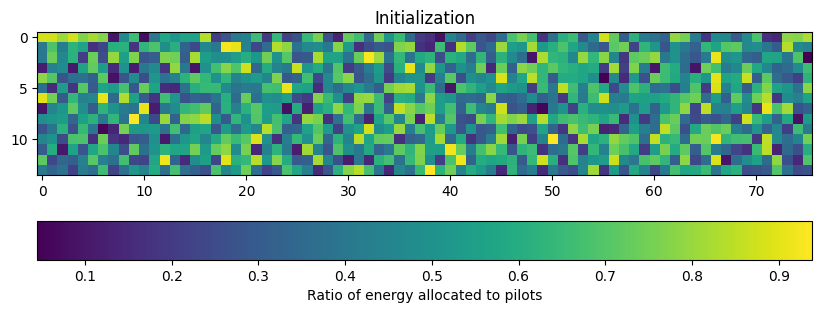

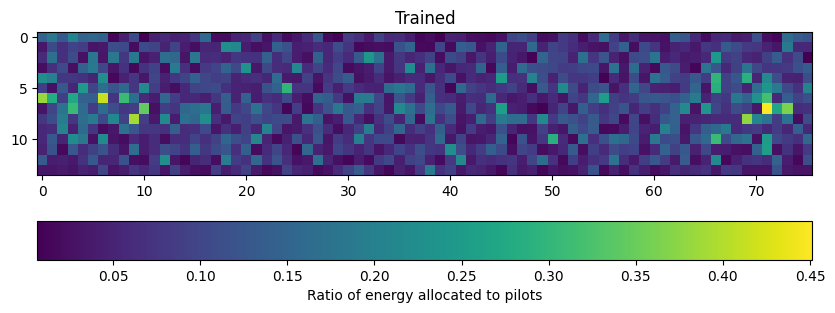

In [8]:
# Instantiating the end-to-end model for evaluation
model = OFDMSystemNeuralReceiver(training=False)

plt.figure(figsize=(10, 4))
plt.imshow(torch.sigmoid(model._scaling_logit[0,0,0]).detach().cpu().numpy())
plt.colorbar(label="Ratio of energy allocated to pilots", orientation="horizontal")
plt.title("Initialization")

# Run one inference to initialize the model
model(1, torch.tensor(10.0, device=device))

# Load the trained weights (strict=False because training model doesn't have encoder/decoder)
model.load_state_dict(torch.load('weights-ofdm-sip.pt', weights_only=True), strict=False)
    
plt.figure(figsize=(10, 4))
plt.imshow(torch.sigmoid(model._scaling_logit[0,0,0]).detach().cpu().numpy())
plt.colorbar(label="Ratio of energy allocated to pilots", orientation="horizontal")
plt.title("Trained");

Finally, we evaluate the performance of our end-to-end system with superimposed pilots and the neural receiver and visualize the bit error rate (BER) curves.

EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
      0.0 | 2.4155e-01 | 1.0000e+00 |       32897 |      136192 |          128 |         128 |         0.1 |reached target block errors
    0.526 | 2.1634e-01 | 1.0000e+00 |       29464 |      136192 |          128 |         128 |         0.0 |reached target block errors
    1.053 | 1.9181e-01 | 1.0000e+00 |       26123 |      136192 |          128 |         128 |         0.0 |reached target block errors
    1.579 | 1.4497e-01 | 9.8438e-01 |       19744 |      136192 |          126 |         128 |         0.0 |reached target block errors
    2.105 | 9.6144e-02 | 8.0469e-01 |       13094 |      136192 |          103 |         128 |         0.0 |reached target block errors
    2.632 | 4.4697e-02 | 3.8802e-01 |       18262 |      408576 |

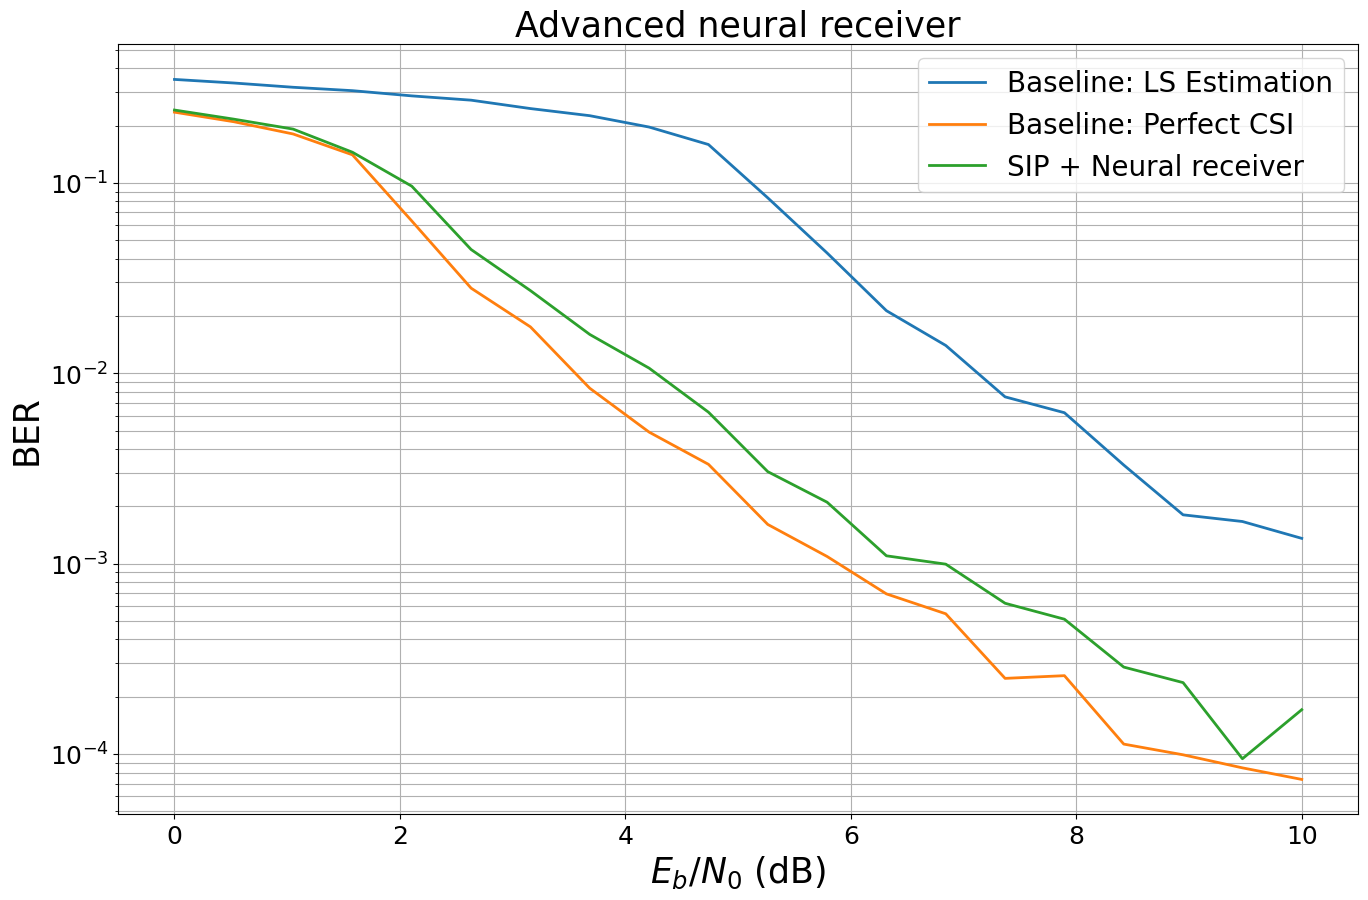

In [9]:
# Computing and plotting BER
ber_plots.simulate(model,
                   ebno_dbs=np.linspace(EBN0_DB_MIN, EBN0_DB_MAX, 20),
                   batch_size=BATCH_SIZE,
                   num_target_block_errors=100,
                   legend="SIP + Neural receiver",
                   max_mc_iter=100,
                   show_fig=True);

## References

[1] F. Ait Aoudia and J. Hoydis, "End-to-end Learning for OFDM: From Neural Receivers to Pilotless Communication," in IEEE Transactions on Wireless Communications, doi: 10.1109/TWC.2021.3101364.

[2] M. Honkala, D. Korpi and J. M. J. Huttunen, "DeepRx: Fully Convolutional Deep Learning Receiver," in IEEE Transactions on Wireless Communications, vol. 20, no. 6, pp. 3925-3940, June 2021, doi: 10.1109/TWC.2021.3054520.

[3] G. Böcherer, "Achievable Rates for Probabilistic Shaping", arXiv:1707.01134, 2017.